In [52]:
# TODO: estimate same data but with hMFC a_i fixed to 1

import dill
import pandas as pd
import jax.numpy as jnp
import numpy as np
import jax.random as jr
from jax import grad, jit, lax, vmap
import matplotlib.pyplot as plt
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

from hmfc_NEW import *


In [53]:

"""
Load in estimated parameters
"""
file_name = '/vsc-hard-mounts/leuven-data/343/vsc34314/Shekhar_2021_nu_mu0.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves
        
        
        

In [54]:

"""
Load in dataset and put in correct format
"""
data = pd.read_csv("/vsc-hard-mounts/leuven-data/343/vsc34314/Shekhar_2021.csv")
#data = pd.read_csv("C:/Users/u0141056/OneDrive - KU Leuven/PhD/PROJECTS/Confidence and hMFC/Analysis/2. Preprocessed data/Shekhar_2021.csv")

num_inputs = 5 # stimulus, prev resp, prev conf, prev resp conf (interaction),  prev stimulus



num_trials_per_subject = jnp.array(data.groupby('subj').size())
max_num_trials = data.groupby('subj').size().max()  # Find the maximum number of observations
num_trials = max_num_trials

inputs, masks = [], []

for i in np.unique(data.subj):
    df = data[data.subj == i]
    
    evidence = jnp.array(df.evidence)  # scaled between -1 and 1
    prevsignabsevi = jnp.array(df.prevsignabsevi)  # interaction prevsign and prevabsevi
    prevresp = jnp.array(df.prevresp)  # -1 left, 1 right
    prevconf = jnp.array(df.prevconf)  # continuous scale between -1 and 1
    prevrespconf = jnp.array(df.prevrespconf)  # interaction between prevresp and prevconf

    resp = jnp.array(df.resp)

    inputs_subj = jnp.vstack([evidence, prevsignabsevi, prevresp, prevconf, prevrespconf]).T
    # MEAN CENTERING THE INPUTS!!!!
    inputs_subj = inputs_subj - jnp.mean(inputs_subj, axis=0)
    emissions_subj = resp
    
    # Create masking variable
    masks_subj = jnp.ones_like(emissions_subj)

    # Append the results to the output lists
    inputs.append(inputs_subj)
    masks.append(masks_subj)

# Convert the lists to arrays
inputs = jnp.array(inputs)
masks = jnp.array(masks)

In [55]:

def sample_emissions_states(key,
           inputs,
           w_i,
           a_i,
           sigmasq_i,
           mu0_i
           ):
    r"""
    Draw emissions and states based on estimated parameters from Shekhar
    """
    num_subjects, num_trials, num_inputs = inputs.shape

    def _sample_one_subject(key, u_i, w_i, a_i, sigmasq_i, mu0_i):
        
        k1, k2, k3, k4, k5, k6, k7 = jr.split(key, 7)

        sigmasq0_i = 1.0
        b_i = mu0_i * (1 - a_i)
        
        # Sample latent states starting at the stationary distribution
        # Stationary covariance is \sigma_0^2 = \sigma^2 / (1 - a^2)
        x_i0 = tfd.Normal(mu0_i, jnp.sqrt(sigmasq0_i)).sample(seed=k5)
  
        def _step(x_it, key):
            x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
            return x_itp1, x_it
        _, x_i = lax.scan(_step, x_i0, jr.split(k6, num_trials))

        # Sample emissions
        y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k7)
        return dict(a=a_i, mu0=mu0_i, w=w_i, sigmasq=sigmasq_i), x_i, y_i

    return vmap(_sample_one_subject)(jr.split(key, num_subjects), inputs, w_i, a_i, sigmasq_i, mu0_i)



In [58]:

"""
Generate emissions and states based on estimated parameters Shekhar
"""
burn_in = 250
a_i = jnp.mean(posterior_samples_a[0,burn_in:,:], axis=0)
sigmasq_i = jnp.mean(posterior_samples_sigmasq[0,burn_in:,:], axis=0)
mu0_i = jnp.mean(posterior_samples_mu0[0,burn_in:,:], axis=0)
w_i = jnp.mean(posterior_samples_w[0,burn_in:,:,:], axis=0)


key = jr.PRNGKey(1)
true_params, true_states, emissions = sample_emissions_states(key, inputs, w_i, a_i, sigmasq_i, mu0_i)


In [80]:
posterior_samples_a0.shape


(2000,)

In [60]:
num_iters = 2000
num_trials = max_num_trials # set to number trials of subject with most trials, masking takes care of the other subjects
num_subjects = len(inputs)



# Make bridge such that hmfc.py can use these variables
model_parameters['num_iters'] = num_iters
model_parameters['num_inputs'] = num_inputs
model_parameters['num_subjects'] = num_subjects
model_parameters['num_trials'] = num_trials


In [61]:

# Initialize model
init_a0 = 0.90
init_nu_a0 = 0.1
init_w0 = jnp.zeros(num_inputs)
init_nu_w0 = jnp.repeat(1.0, num_inputs)
init_alpha = 3.0
init_beta = 3.0 * 0.3**2
init_nu_mu0 = 0.5

model = HierarchicalBernoulliLDS(init_a0, init_nu_a0, init_w0, init_nu_w0, init_alpha, init_beta, init_nu_mu0)
params, states, _ = model.sample(key, inputs)


In [16]:
states.shape

(20, 2799)

In [62]:
"""
Fit model
"""

lps = jnp.zeros((num_iters,)) # log probability

posterior_samples_a0 = jnp.zeros((num_iters,))
posterior_samples_nu_a0 = jnp.zeros((num_iters,))
posterior_samples_w0 = jnp.zeros((num_iters, num_inputs))
posterior_samples_nu_w0 = jnp.zeros((num_iters, num_inputs))
posterior_samples_alpha = jnp.zeros((num_iters,))
posterior_samples_beta = jnp.zeros((num_iters,))
posterior_samples_nu_mu0 = jnp.zeros((num_iters,))

posterior_samples_a = jnp.zeros((num_iters, num_subjects))
posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
posterior_samples_mu0 = jnp.zeros((num_iters, num_subjects))

posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))

for itr in progress_bar(range(num_iters)):

    this_key, key = jr.split(key)
    lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model)
    
    lps = lps.at[itr].set(lp)

    posterior_samples_a0 = posterior_samples_a0.at[itr].set(sigmoid(model.logit_a_0))
    posterior_samples_nu_a0 = posterior_samples_nu_a0.at[itr].set(jnp.exp(model.log_nu_a))
    posterior_samples_w0 = posterior_samples_w0.at[itr].set(model.w_0)
    posterior_samples_nu_w0 = posterior_samples_nu_w0.at[itr].set(jnp.exp(model.log_nu_w))
    posterior_samples_alpha = posterior_samples_alpha.at[itr].set(jnp.exp(model.log_alpha))
    posterior_samples_beta = posterior_samples_beta.at[itr].set(jnp.exp(model.log_beta))
    posterior_samples_nu_mu0 = posterior_samples_nu_mu0.at[itr].set(jnp.exp(model.log_nu_mu0))


    posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
    posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
    posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
    posterior_samples_mu0 = posterior_samples_mu0.at[itr].set(params['mu0'])
    
    posterior_samples_states = posterior_samples_states.at[itr].set(states)

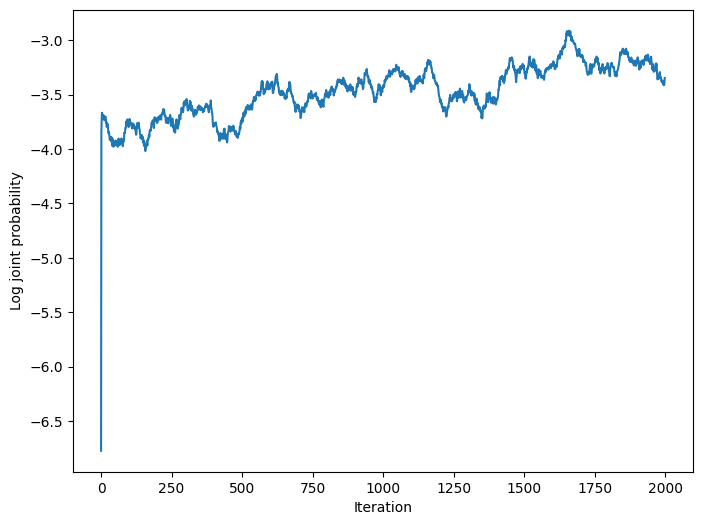

In [63]:

burn_in = 100 # choose a different value informed by the plot below

plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps)/emissions.size) # normalized log joint prob
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.show()


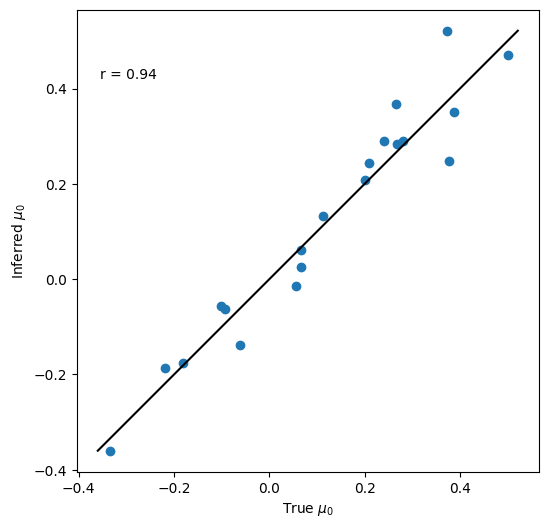

In [77]:
""" Compare true and inferred estimates of mu0 averaged over iterations (minus the burn-in)
"""

# Compute posterior mean of a for each subject over iterations
posterior_mean_mu0 = jnp.mean(posterior_samples_mu0[burn_in:], axis=0)

mu0_min = min(true_params['mu0'].min(), posterior_mean_mu0.min())
mu0_max = max(true_params['mu0'].max(), posterior_mean_mu0.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['mu0'], posterior_mean_mu0)
plt.plot([mu0_min, mu0_max], [mu0_min, mu0_max], '-k')
plt.xlabel("True $\mu_0$")
plt.ylabel("Inferred $\mu_0$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['mu0'], posterior_mean_mu0)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

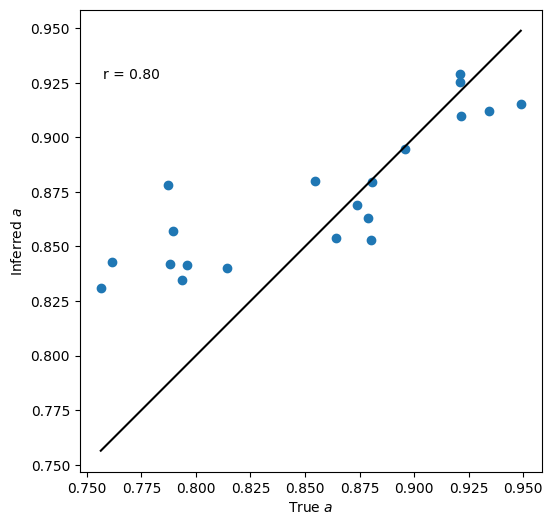

In [64]:
""" Compare true and inferred estimates of a_i averaged over iterations (minus the burn-in)
"""

# Compute posterior mean of a for each subject over iterations
posterior_mean_a = jnp.mean(posterior_samples_a[burn_in:], axis=0)

a_min = min(true_params['a'].min(), posterior_mean_a.min())
a_max = max(true_params['a'].max(), posterior_mean_a.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['a'], posterior_mean_a)
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$")
plt.ylabel("Inferred $a$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['a'], posterior_mean_a)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

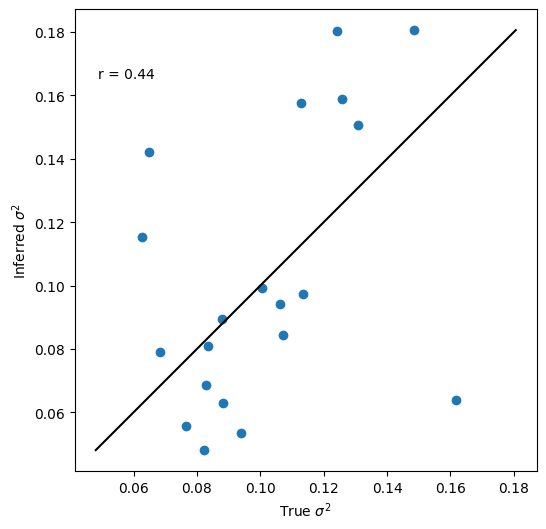

In [78]:


""" Compare true and inferred estimates of sigma_sq averaged over iterations (minus the burn-in)
"""

posterior_mean_sigmasq = jnp.mean(posterior_samples_sigmasq[burn_in:], axis=0)

sigmasq_min = min(true_params['sigmasq'].min(), posterior_mean_sigmasq.min())
sigmasq_max = max(true_params['sigmasq'].max(), posterior_mean_sigmasq.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['sigmasq'], posterior_mean_sigmasq)
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$")
plt.ylabel("Inferred $\sigma^2$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['sigmasq'], posterior_mean_sigmasq)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

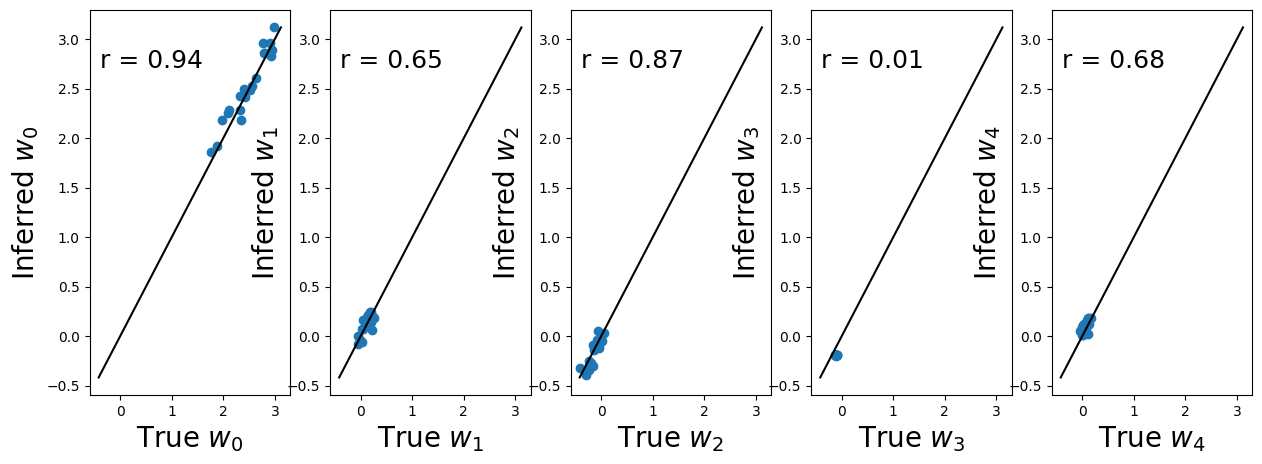

In [82]:

""" Compare true and inferred estimates of w averaged over iterations (minus the burn-in)
"""
    
w_min = min(true_params["w"].min(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).min())
w_max = max(true_params["w"].max(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=False, figsize=(15, 5))

for d, ax in enumerate(axs):
    ax.scatter(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d), size=20)
    ax.set_ylabel(r"Inferred $w_{:d}$".format(d), size=20)
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    #ax.set_aspect(1.0)
    r, p = spearmanr(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=18)



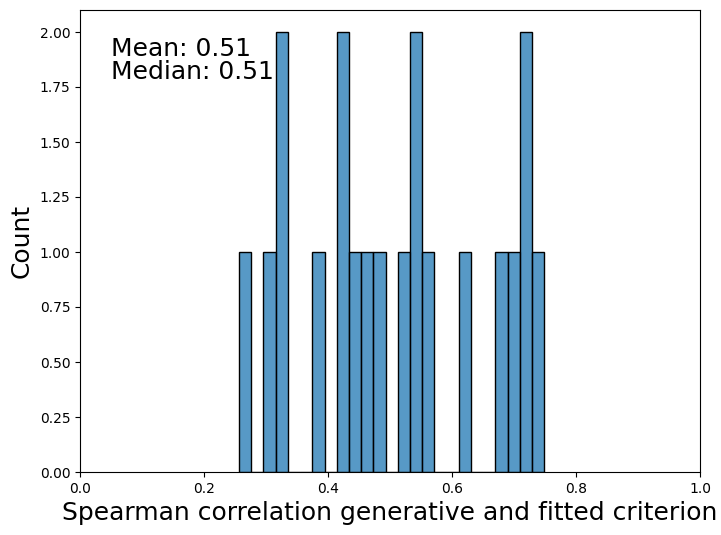

In [67]:

# Correlation between inferred and fitted criterion trajectories

posterior_samples_states_mean = jnp.mean(posterior_samples_states[burn_in:,:,:], axis=0) 
posterior_samples_states_std = jnp.std(posterior_samples_states[burn_in:,:,:], axis=0)


correlations_inferred_and_fitted_states = jnp.array([spearmanr(true_states[subject], posterior_samples_states_mean[subject])[0] for subject in range(num_subjects)])

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(correlations_inferred_and_fitted_states, bins=25)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=18)
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=18)
plt.xlabel('Spearman correlation generative and fitted criterion', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.xlim(0, 1)
plt.show()



Text(0.05, 0.9, 'r = 0.33')

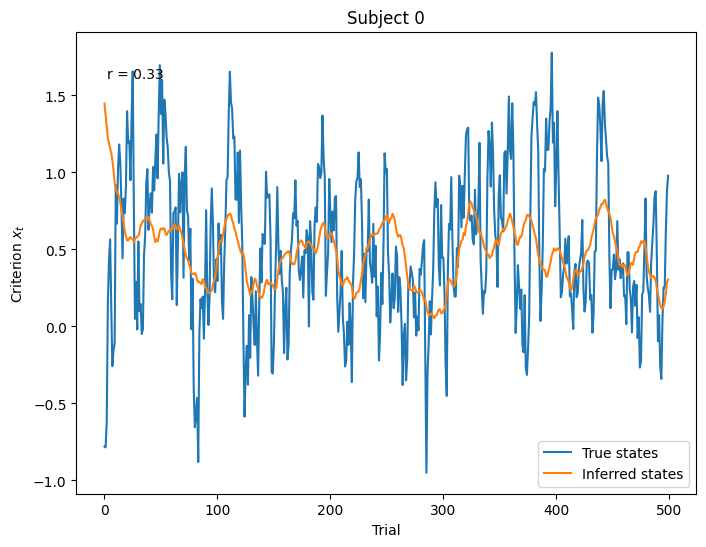

In [87]:
subject = 0
trial_limit = 500
plt.figure(figsize=(8, 6))
plt.plot(true_states[subject][:trial_limit], label="True states")
plt.plot(posterior_samples_states_mean[subject][:trial_limit], label="Inferred states")
# plt.fill_between(jnp.arange(num_trials), #95% CI
#           posterior_samples_states_mean[subject] - 2 * posterior_samples_states_std[subject],
#           posterior_samples_states_mean[subject] + 2 * posterior_samples_states_std[subject], color='r', alpha=0.25)
plt.xlabel("Trial")
plt.ylabel("Criterion $x_t$")
plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='lower right')
r, p = spearmanr(true_states[subject][:trial_limit], posterior_samples_states_mean[subject][:trial_limit])
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
